# sc_inj: The LCLS-II injector

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

In [2]:
from astra import Astra
from distgen import Generator
import os

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


# Distgen

In [3]:
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'

G = Generator(DISTGEN_IN)
G['n_particle'] = 100000
G

<disgten.Generator with input: 
n_particle: 100000
r_dist:
  max_r:
    units: mm
    value: 0.5
  type: radial_uniform
random_type: hammersley
start:
  MTE:
    units: meV
    value: 330
  type: cathode
t_dist:
  avg_t:
    units: ps
    value: 0
  n_sigma_cutoff: 3
  sigma_t:
    units: ps
    value: 8.5
  type: gaussian
total_charge:
  units: pC
  value: 100

>

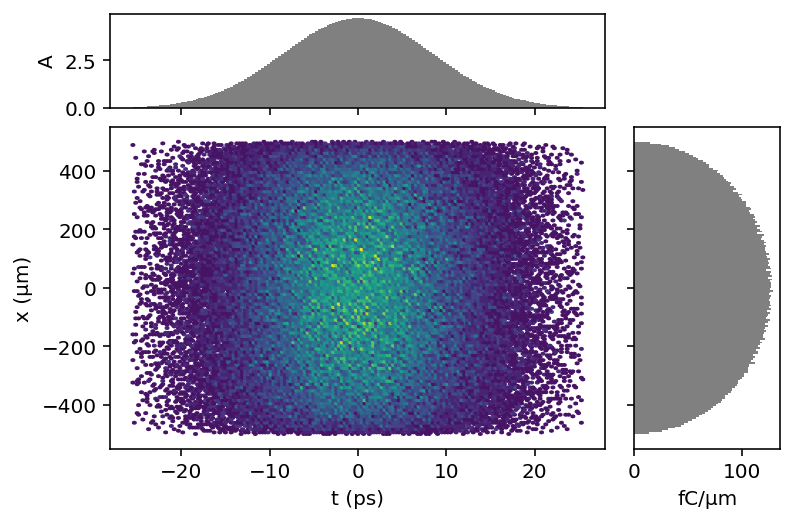

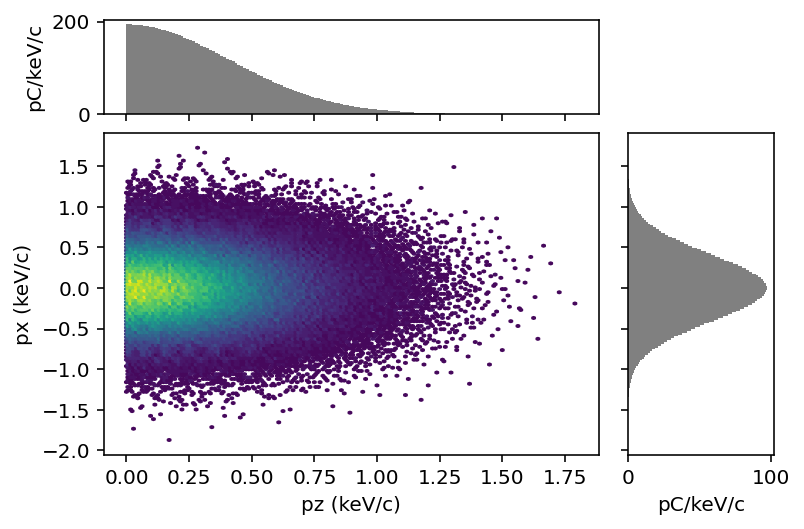

In [4]:
# Make the particles
G.run()
P0 = G.particles
P0.plot('t', 'x')
P0.plot('pz', 'px')

# Astra

In [5]:
ASTRA_IN = '$LCLS_LATTICE/astra/models/sc_inj/v0/astra.in'

In [6]:
A = Astra(ASTRA_IN, initial_particles=P0, verbose=True)
#A.input['charge']['lspch'] = False

In [7]:
A.run()

Initial particles written to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpsuwl1pbc/astra.particles
/var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpsuwl1pbc/astra.particles exists, will not symlink
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/187MHz_HighDef_March2010.dat to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpsuwl1pbc/187MHz_HighDef_March2010.dat
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/APEX2cellBuncher.dat to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpsuwl1pbc/APEX2cellBuncher.dat
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpsuwl1pbc/9cell1300.cav
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav to /var/folders/wj/lfgr01993dx79p9cm_skykbw0000gn/T/tmpsuwl1pbc/9cell1300.cav
Linked /Users/chrisonian/Code/GitHub/lcls-lattice/astra/fieldmaps/9cell1300.cav to /var/folders/wj/lfgr01993dx79p9cm

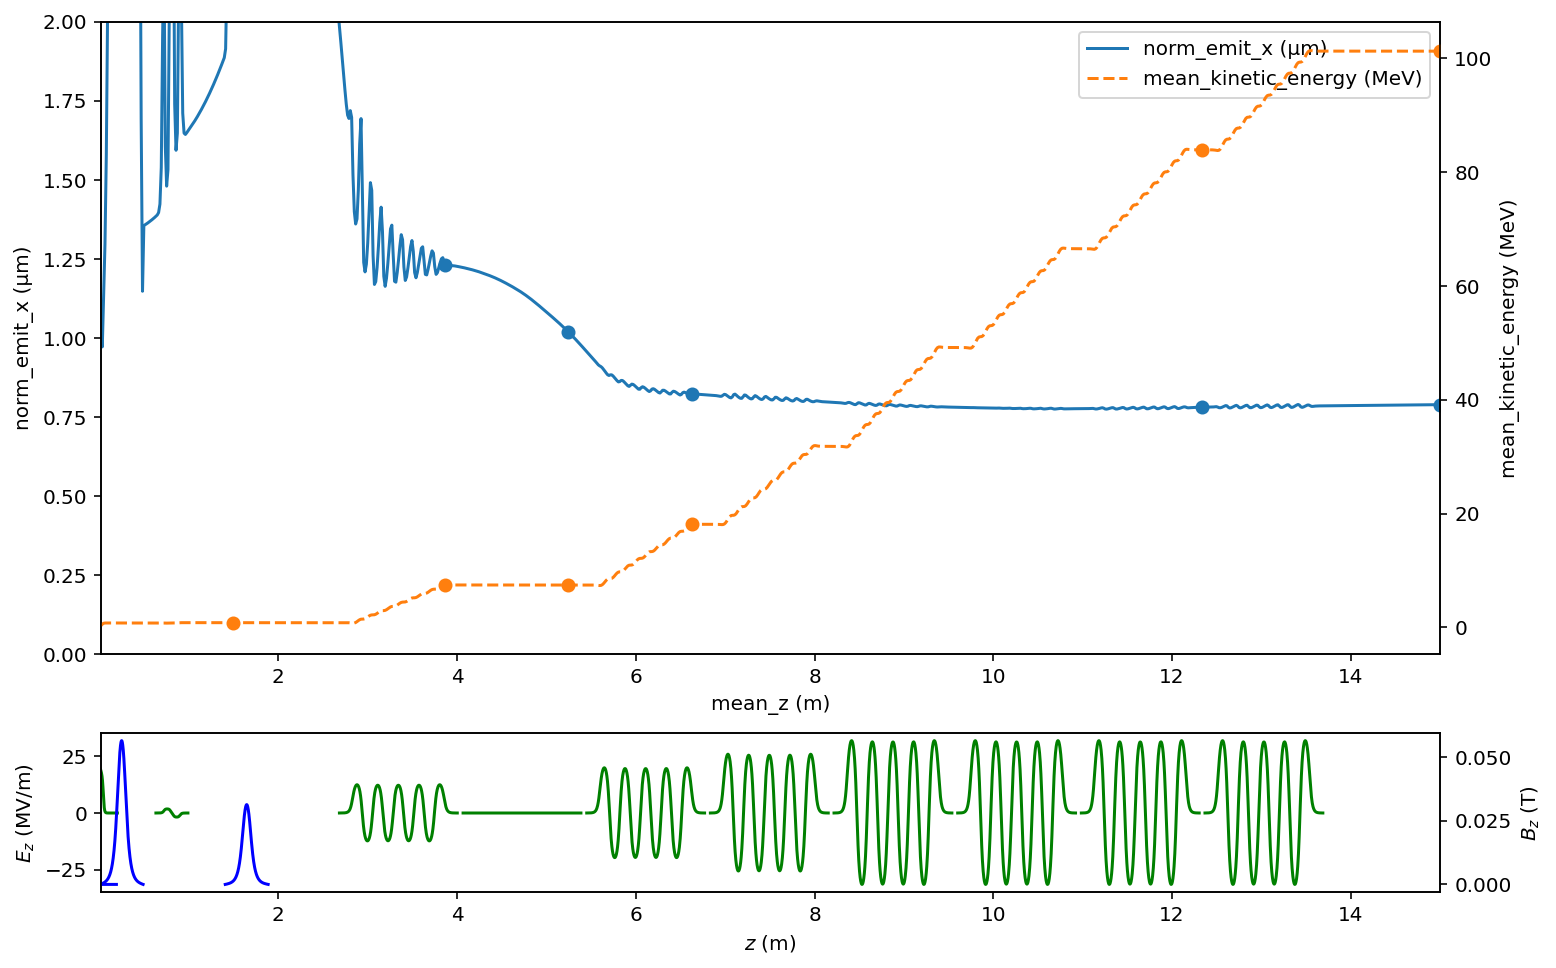

In [8]:
A.verbose=False
A.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

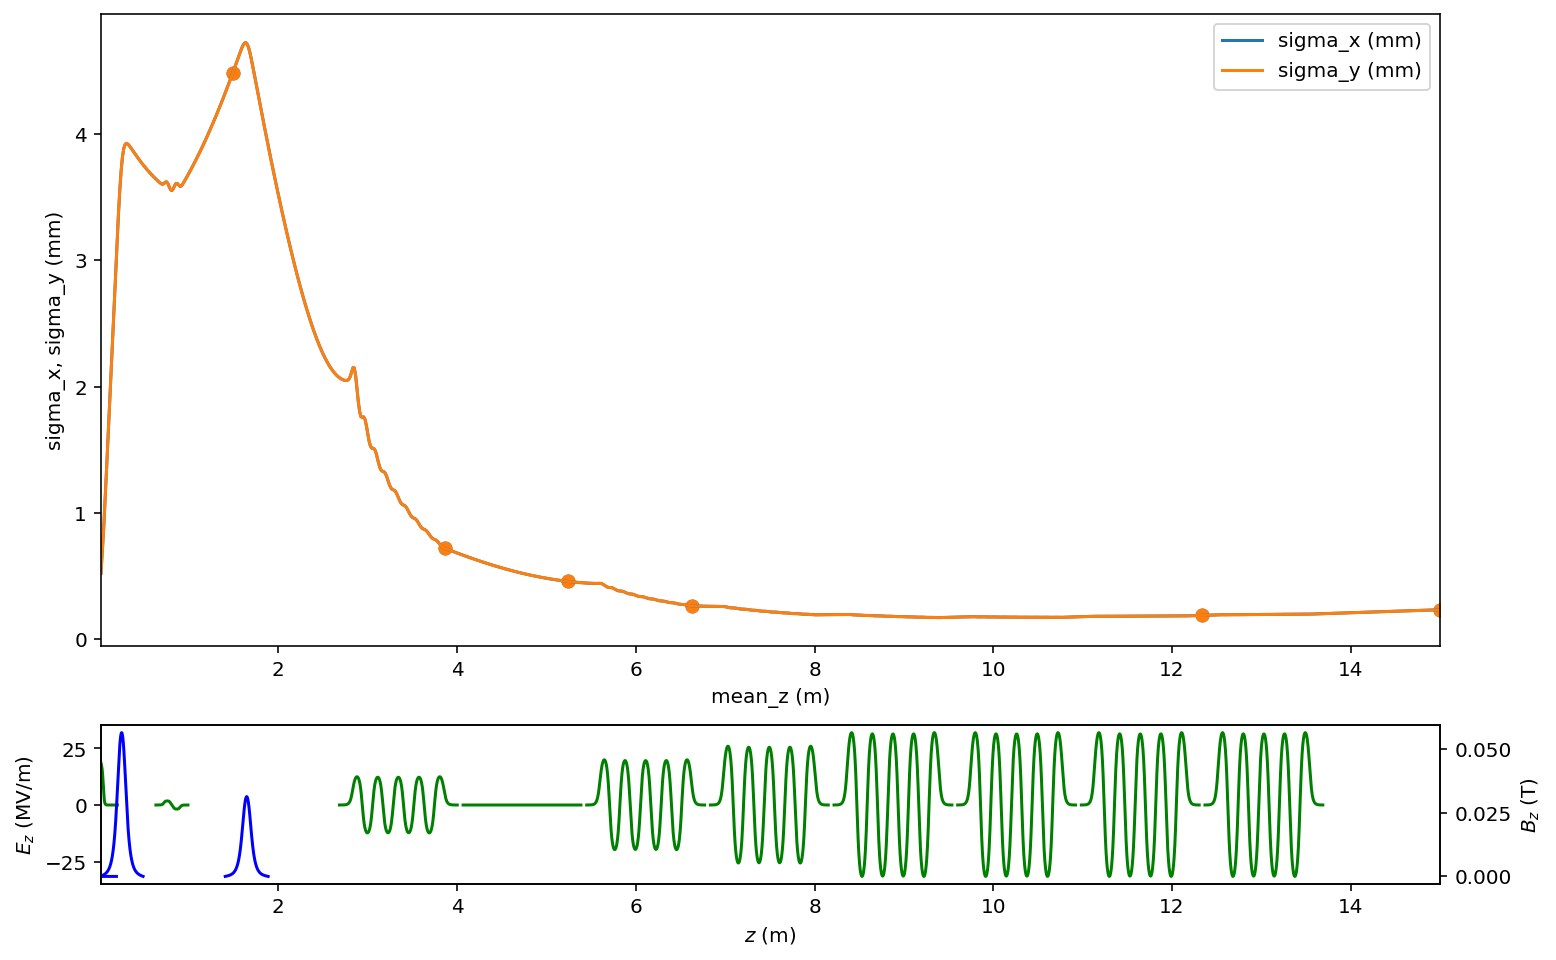

In [9]:
A.plot(['sigma_x', 'sigma_y'], figsize=(12,8))

In [10]:
Pf = A.particles[-1]

In [11]:
Pf.twiss('xy', 0.95)

{'alpha_x': -1.8994015755043332,
 'beta_x': 16.078815102880036,
 'gamma_x': 0.28657126259278937,
 'emit_x': 2.57044127876966e-09,
 'eta_x': -0.0008435477154074869,
 'etap_x': -2.926349857311034e-05,
 'norm_emit_x': 5.120533108762901e-07,
 'alpha_y': -1.9036986622010736,
 'beta_y': 16.126093553737103,
 'gamma_y': 0.28674449773327554,
 'emit_y': 2.569628585026964e-09,
 'eta_y': -0.0004280507076635248,
 'etap_y': -2.5343742272326806e-05,
 'norm_emit_y': 5.118913506442581e-07}

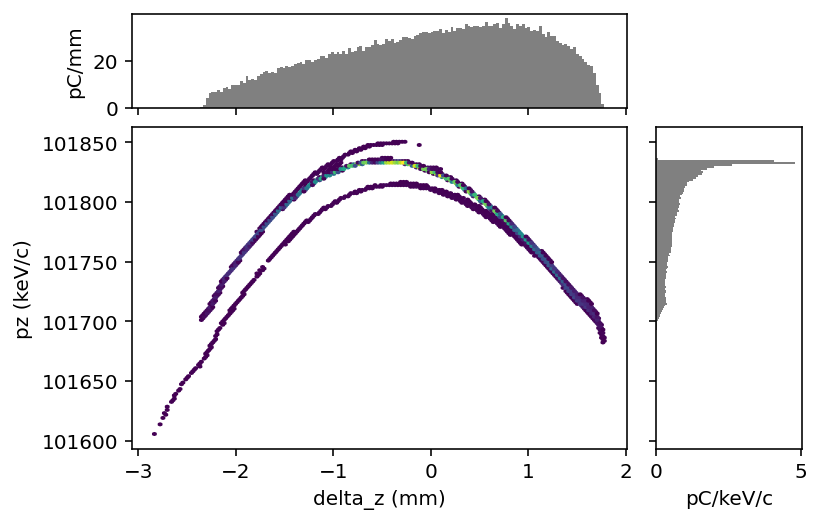

In [12]:
Pf.plot('delta_z', 'pz')

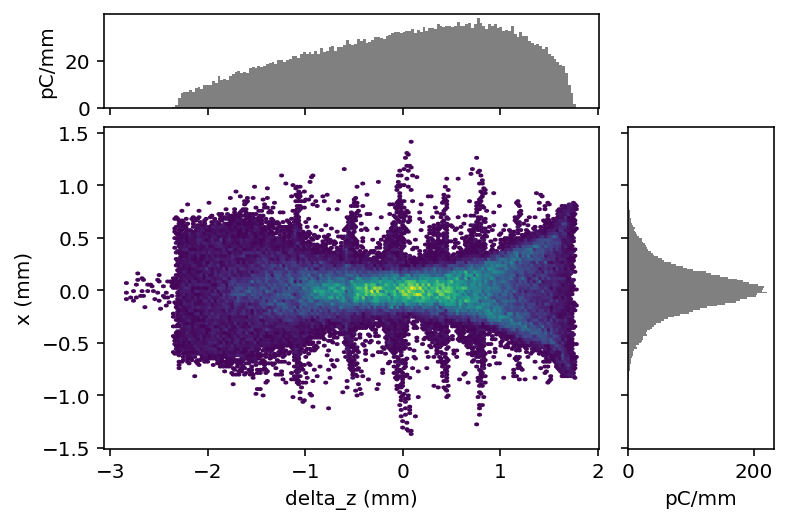

In [13]:
Pf.plot('delta_z', 'x')

# Scan final cavity

In [14]:
from concurrent.futures import ProcessPoolExecutor

In [15]:
# Allows processes to work with macOS
from sys import platform 
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [16]:
def set1(phi_deg):
    
    A2 = A.copy()
    A2.verbose=False
    A2.initial_particles =  A.particles[-2]
    A2.configure()
    A2.input['charge']['lspch'] = False
    A2.input['cavity']['phi(9)'] = 0
    A2.input['cavity']['phi(10)'] = phi_deg
    A2.run()
    return A2.particles[-1]
    
#set1(0)    
    

In [17]:
xlist = np.linspace(-10, 0, 24)

In [18]:
%%time
with ProcessPoolExecutor(max_workers=4) as executor:
    results1 = list(executor.map(set1, xlist))

CPU times: user 253 ms, sys: 398 ms, total: 651 ms
Wall time: 9min 55s


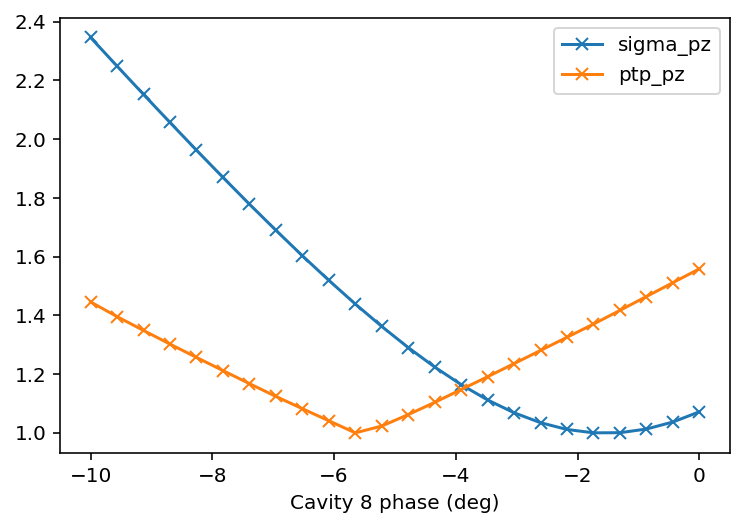

In [19]:
spz = np.array([P['sigma_pz'] for P in results1])
ptp_pz = np.array([P['ptp_pz'] for P in results1])
plt.plot(xlist, spz/spz.min(), marker='x', label='sigma_pz')
plt.plot(xlist, ptp_pz/ptp_pz.min(), marker='x', label='ptp_pz')
plt.xlabel('Cavity 8 phase (deg)')
plt.legend()

In [20]:
xlist[ptp_pz.argmin()], xlist[spz.argmin()]

(-5.6521739130434785, -1.7391304347826093)

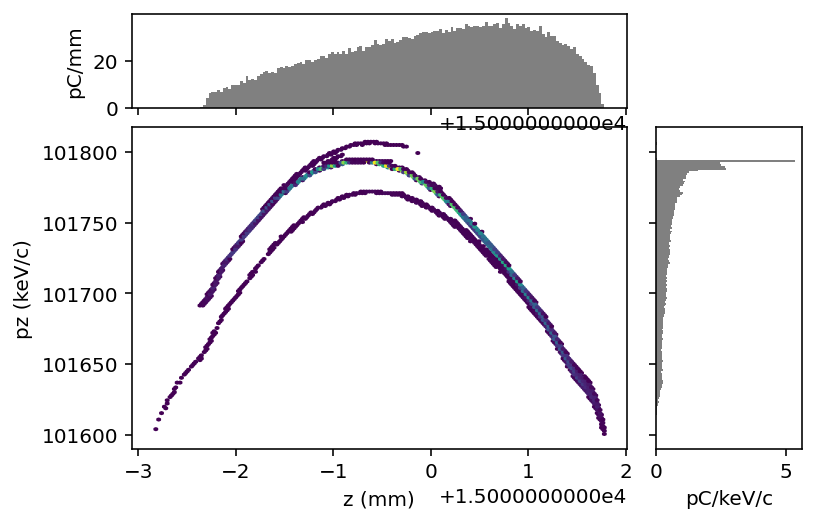

In [21]:
results1[ptp_pz.argmin()].plot('z', 'pz')

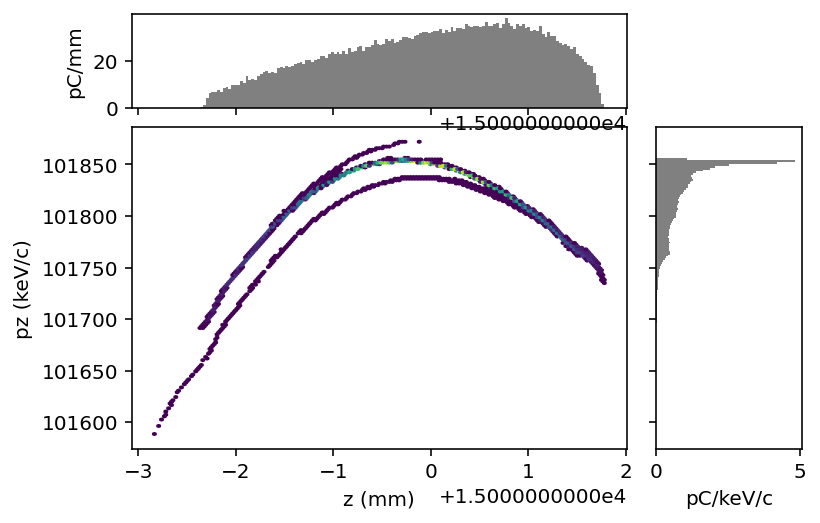

In [22]:
results1[spz.argmin()].plot('z', 'pz')

# Visualization

Run with fewer particles

In [23]:
A = Astra(ASTRA_IN, initial_particles=P0.resample(10000))
#A.verbose=True
A.input['charge']['nrad']= 20
A.input['charge']['nlong_in'] = 43

# Remove screens, because they conflict with zphase outpt
for k in list(A.input['output']):
    if k.startswith('screen'):
        A.input['output'].pop(k)
A.input['output']['zphase'] = 1000

In [24]:
%%time
A.run()

CPU times: user 1min 40s, sys: 1.67 s, total: 1min 41s
Wall time: 8min 28s


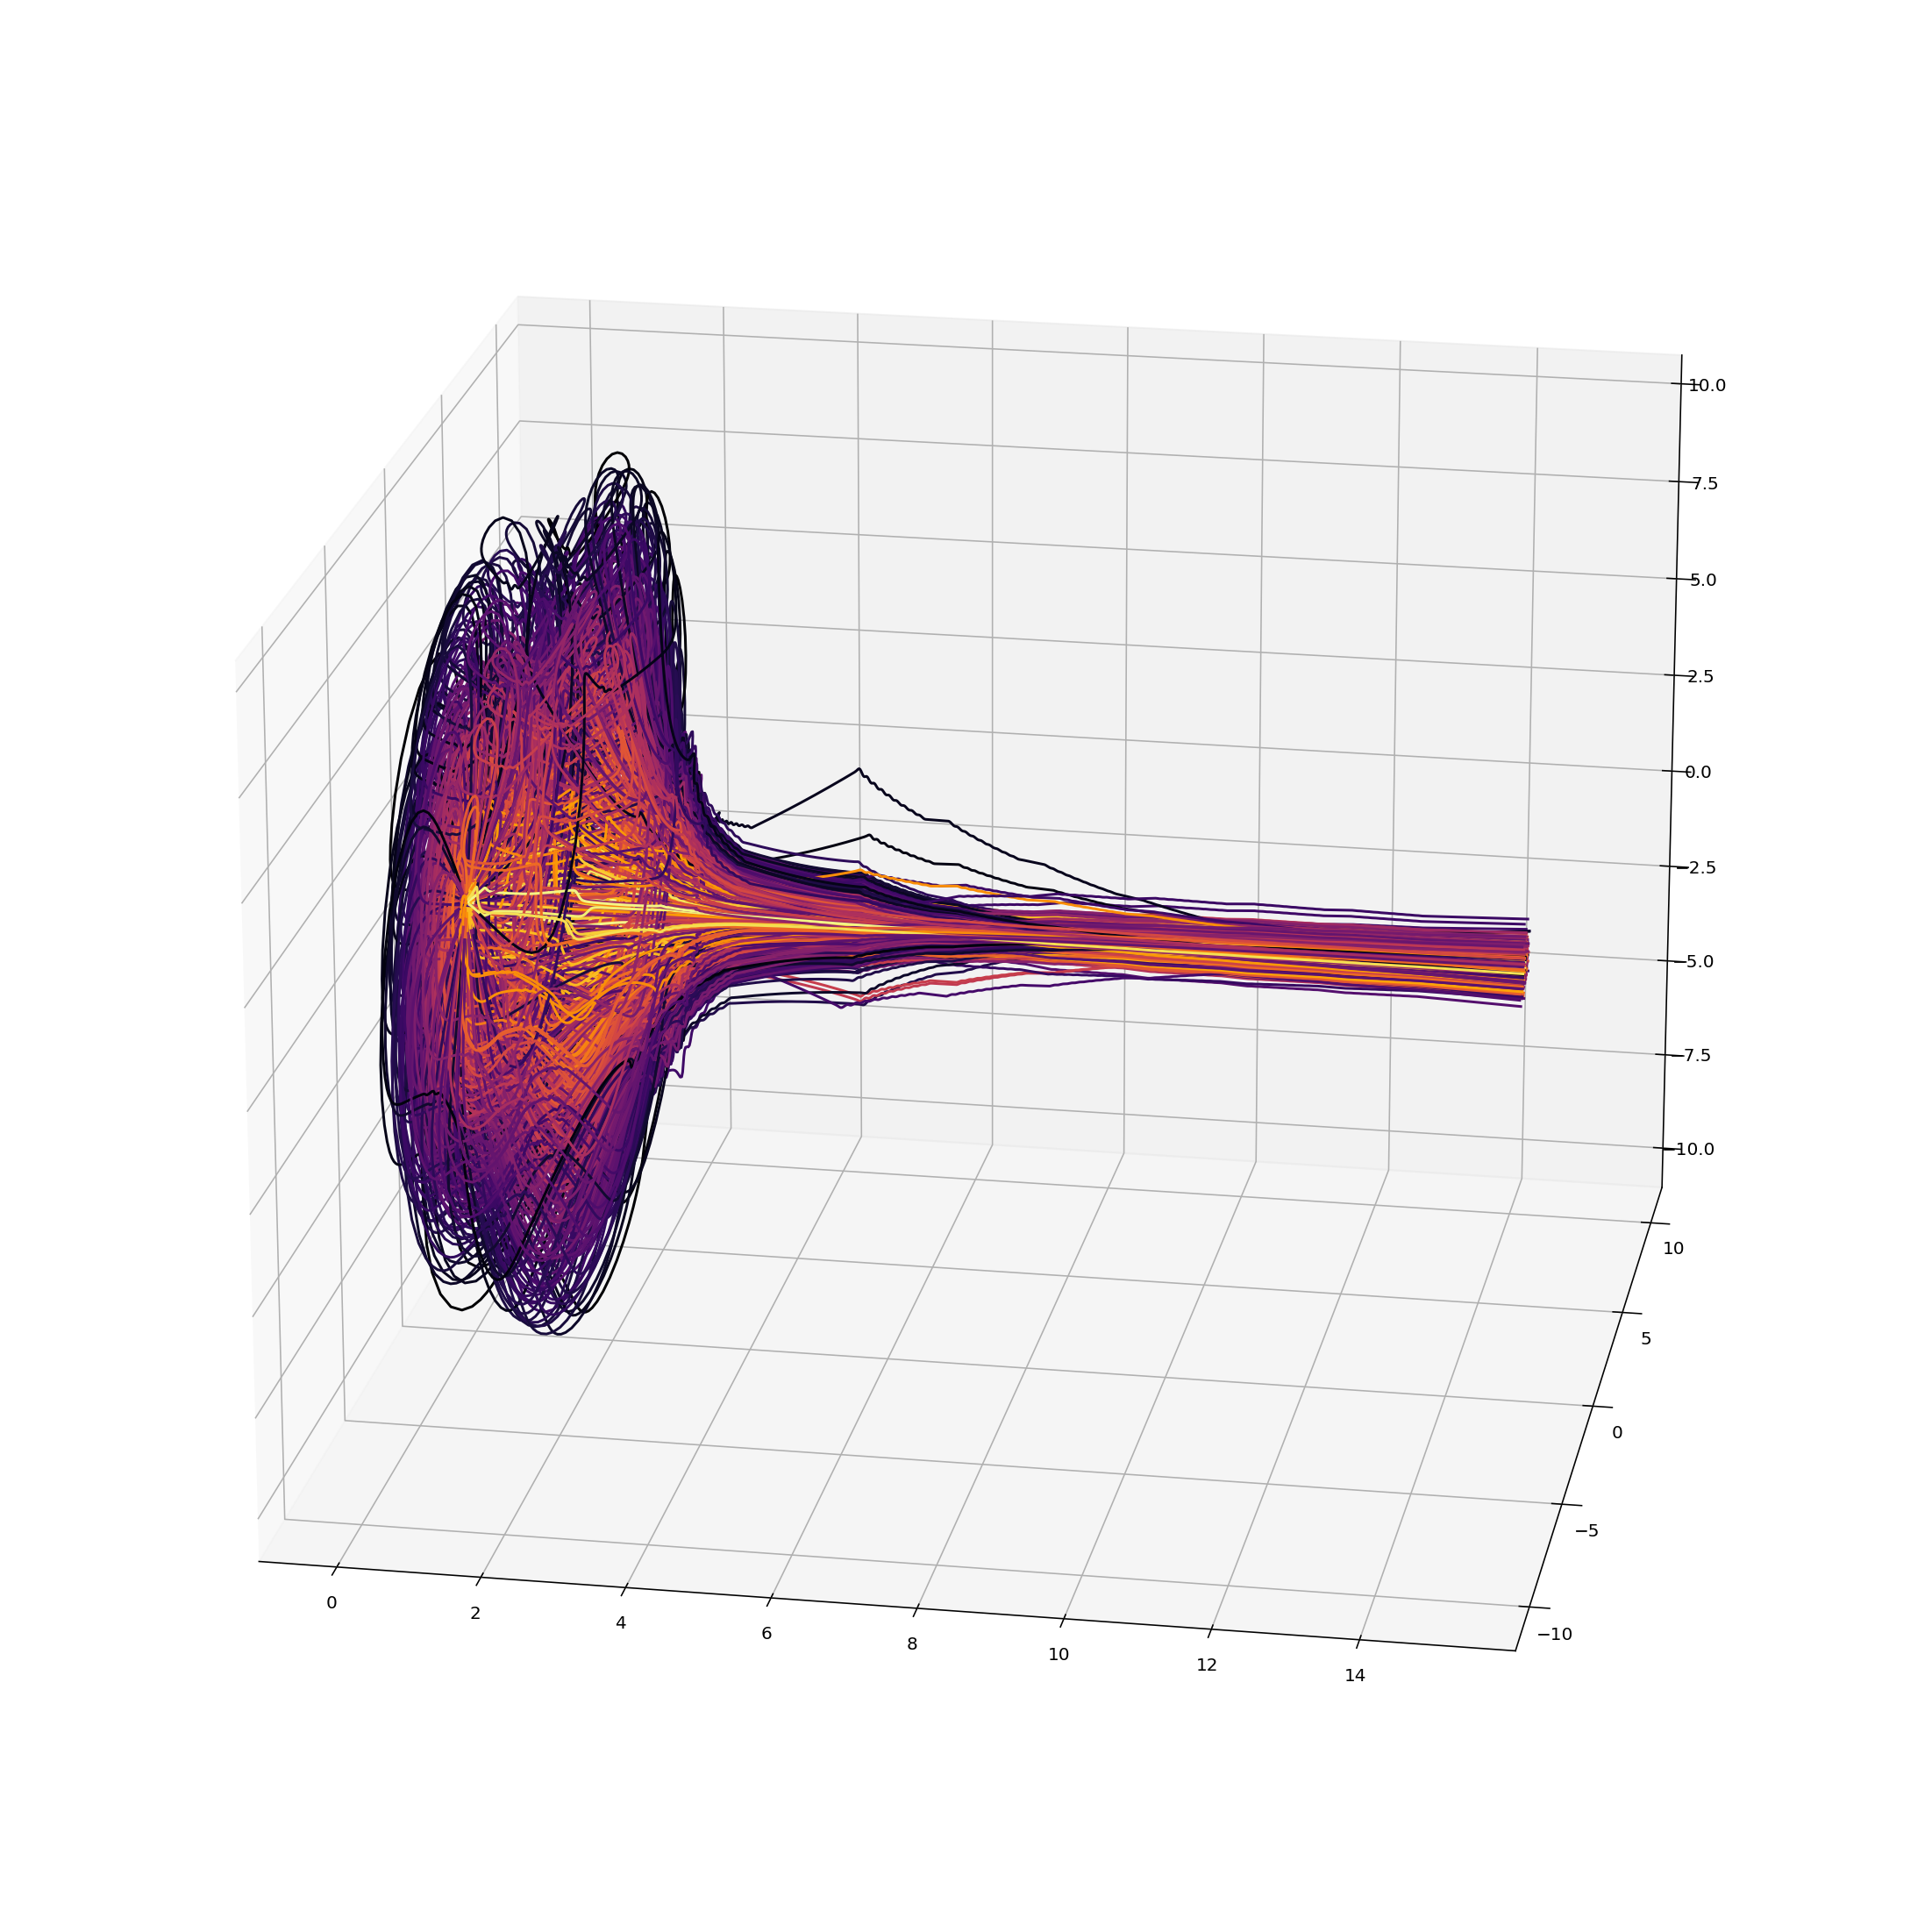

In [25]:
# 3D plot
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111, projection='3d')
cmap = matplotlib.cm.get_cmap('inferno')

skip = 10

X = np.array([P.x[::skip] for P in  A.particles]).T
Y = np.array([P.y[::skip]  for P in  A.particles]).T
Z = np.array([P.z[::skip]  for P in  A.particles]).T

scale = np.hypot(X[:, 0], Y[:,0]).max()



for i in range(len(X)):
    color = cmap(1-np.hypot(X[i,0], Y[i,0])/scale)
    ax.plot(X[i]*1000, Y[i]*1000, Z[i], zdir='x', color=color)
    
ax.view_init(20, 280)    

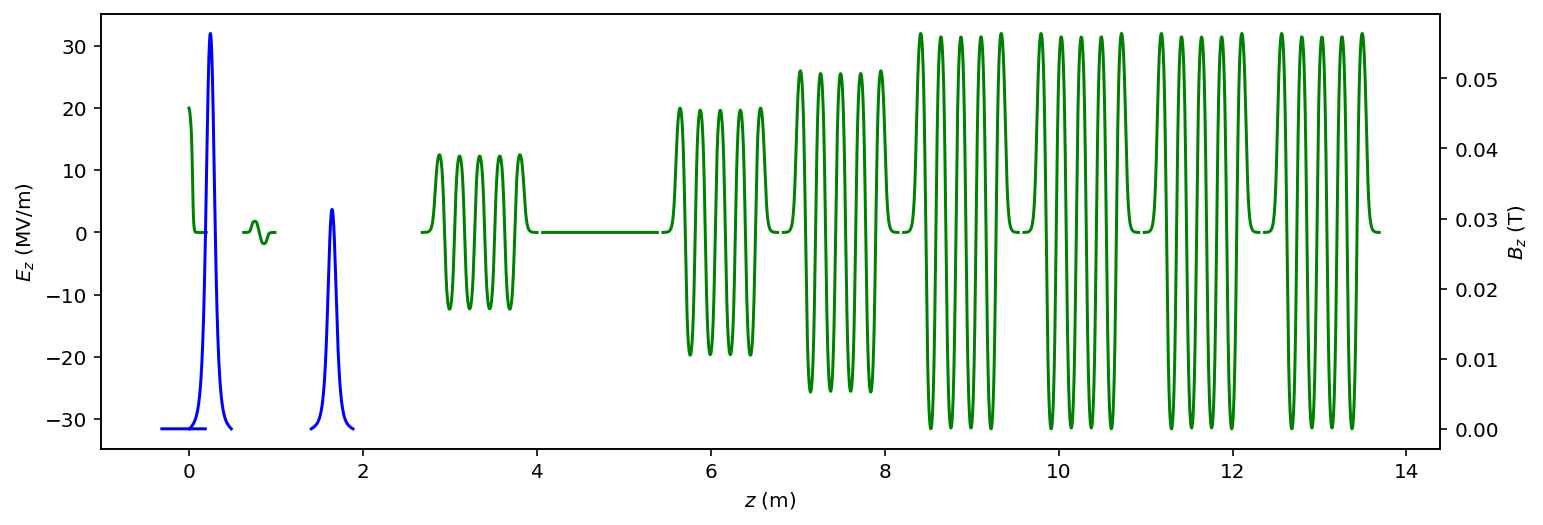

In [26]:
fig=A.plot_fieldmaps()

In [27]:
from astra.plot import add_fieldmaps_to_axes

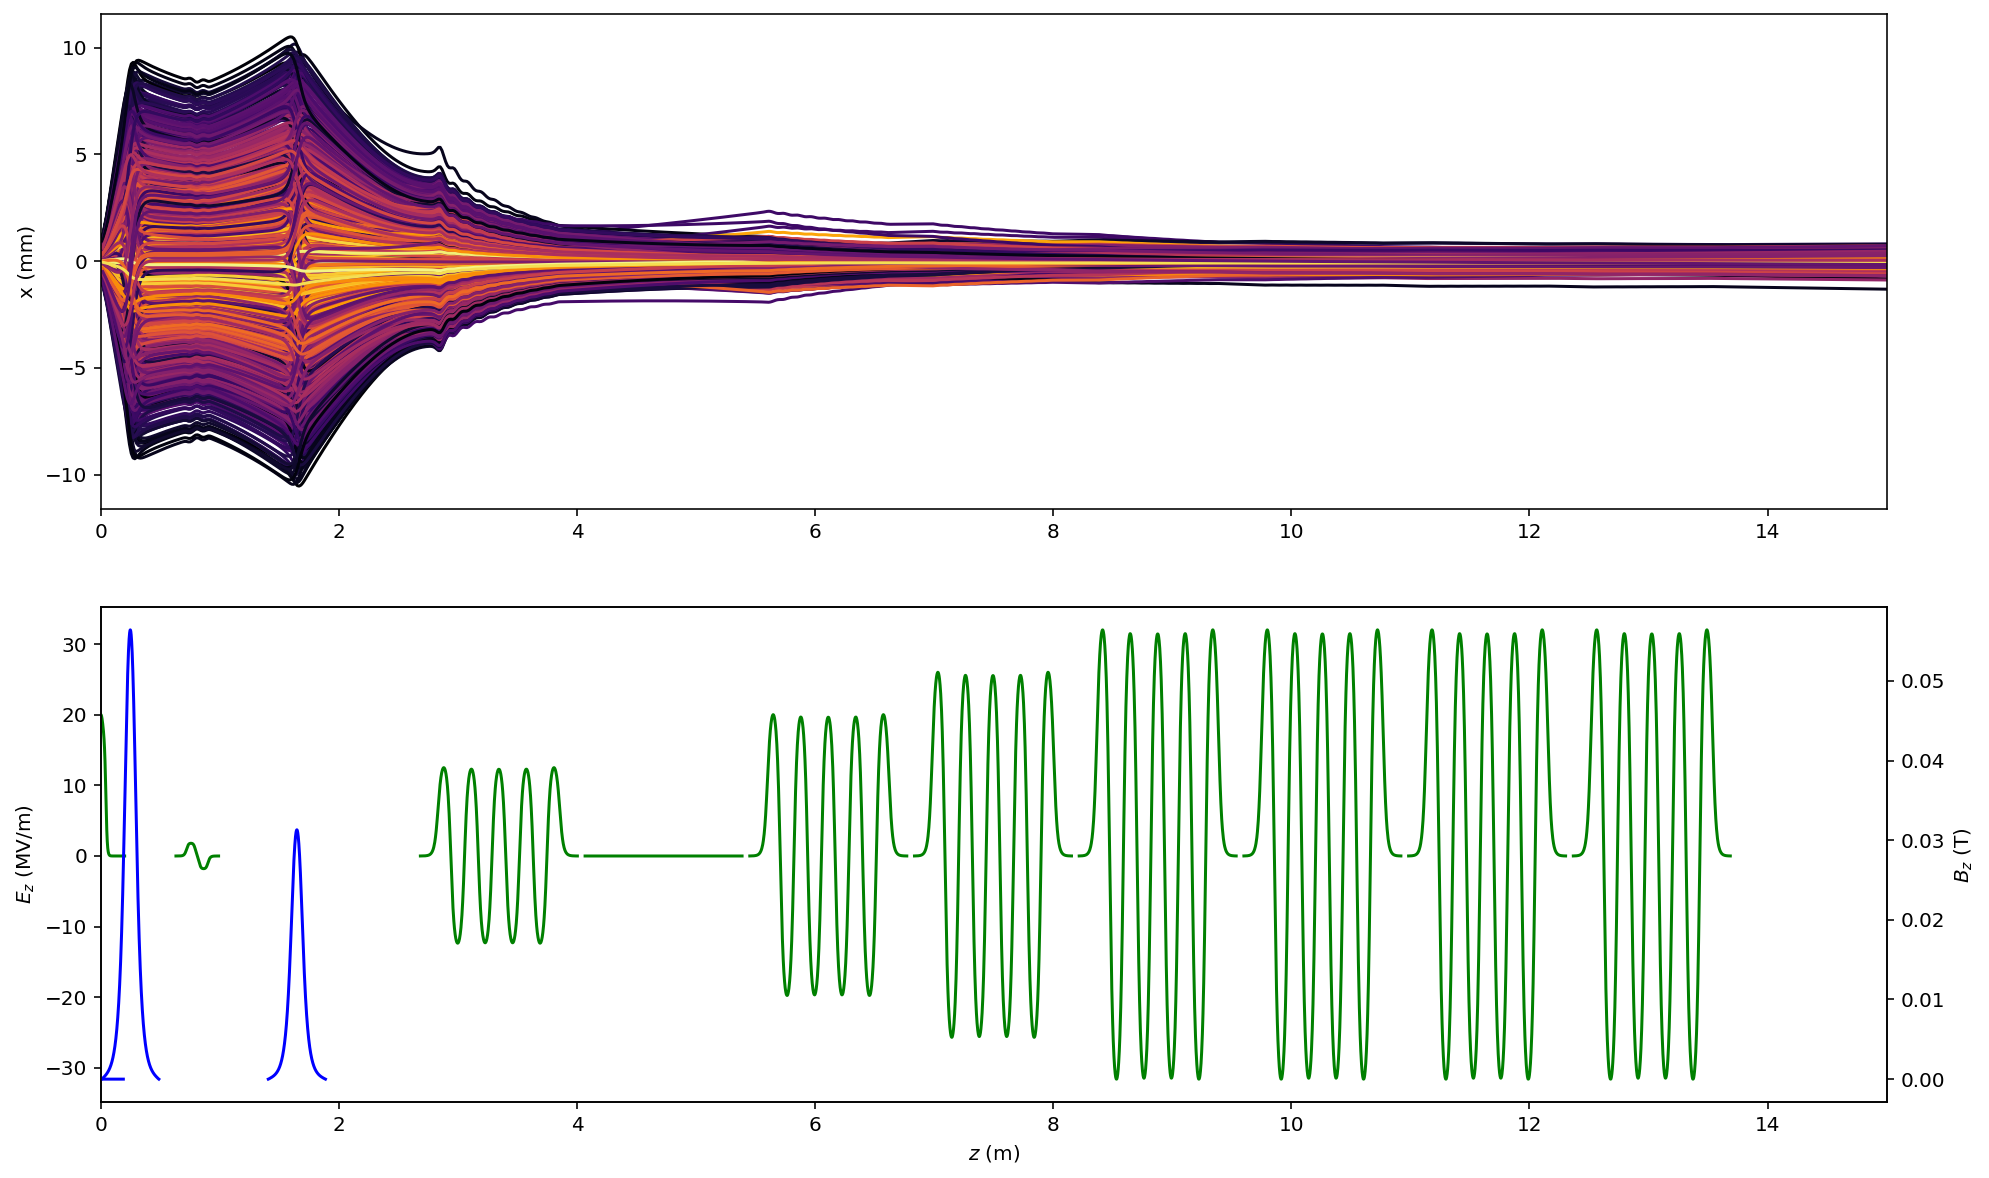

In [28]:
XLIM = (0,15)

fig, axes = plt.subplots(2, 1, figsize=(16,10))
ax = axes[0]
ax_layout = axes[1]
for i in range(len(X)):
    color = cmap(1-np.hypot(X[i,0], Y[i,0])/scale)
    ax.plot( Z[i], X[i]*1000,  color=color)
    
ax.set_ylabel('x (mm)')
ax.set_xlim(*XLIM)
add_fieldmaps_to_axes(A,  ax_layout, bounds=XLIM, include_labels=True)      